In [1]:
import os
import pickle
import pprint
import warnings
from concurrent.futures import ProcessPoolExecutor, as_completed

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import yaml
from stable_baselines3 import DQN
from tqdm import tqdm

from crl.agents import learn_cqldqn_policy, learn_ddqn_policy, learn_dqn_policy
from crl.calib import (
    collect_transitions,
    compute_corrections,
    correction_for,
    fill_calib_sets_mc,
    fill_calib_sets_td,
    signed_score,
)
from crl.ccnn import calibrate_ccnn, run_ccnn_experiment
from crl.discretise import build_tile_coding
from crl.env import instantiate_eval_env
from crl.types import AgentTypes, CalibMethods, ClassicControl, ScoringMethod
from crl.utils.graphing import despine

/Users/alexinch/Desktop/noodling/msc_thesis/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
ALPHA_DISC = 0.01           # Conformal prediction miscoverage level (discrete algo)
ALPHA_NN = 0.1              # Conformal prediction miscoverage level (nearest neighbour algo)
CQL_ALPHA = 0.05
MIN_CALIB = 50              # Minimum threshold for a calibration set to be leveraged
NUM_EXPERIMENTS = 25
NUM_EVAL_EPISODES = 250
N_CALIB_STEPS = 10_000
N_TRAIN_STEPS = 50_000
K = 50
SCORING_METHOD: ScoringMethod = 'td'
AGENT_TYPE: AgentTypes = 'vanilla'
SCORE_FN = signed_score
RETRAIN = False
CALIB_METHODS: list[CalibMethods] = ['nocalib', 'ccdisc', 'ccnn']
CCNN_MAX_DISTANCE_QUANTILE = 0.9

In [3]:
import os
import torch
import ale_py
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3.common.monitor import Monitor

ENV_ID = "BreakoutNoFrameskip-v4"  # classic ALE id suitable for DQN/Atari wrappers
SEED = 0

log_dir = "/tmp/gym/"
os.makedirs(log_dir, exist_ok=True)
# 1) Make and wrap the env (DeepMind-style preprocessing + VecFrameStack(4))
train_env = make_atari_env(ENV_ID, n_envs=1, seed=SEED, monitor_dir=log_dir)
train_env = VecFrameStack(train_env, n_stack=4)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


In [4]:
model = DQN.load('../../models/BreakoutNoFrameskip-v4/BreakoutNoFrameskip-v4_2/best_model.zip')

In [5]:
eval_env = make_atari_env(ENV_ID, n_envs=1, seed=SEED + 1)
eval_env = VecFrameStack(eval_env, n_stack=4)
rewards, lengths = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True, return_episode_rewards=True)

In [6]:
def iqm(rewards: list[float]):
    q25, q75 = np.percentile(rewards, q=[25, 75])
    rewards_iq = [r for r in rewards if q25 <= r <= q75]
    return np.mean(rewards_iq)

In [7]:
print(f'Mean: {np.mean(rewards):.1f} ± {np.std(rewards):.1f}')
print(f'IQM: {iqm(rewards):.1f}')

Mean: 391.4 ± 9.0
IQM: 395.0


In [8]:
list(range(0, 45, 4))

[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44]

In [9]:
mode_results = {}
for mode in range(0, 45, 4):
    eval_env = make_atari_env(ENV_ID, n_envs=1, seed=SEED + 1, env_kwargs={'difficulty': 0, 'mode': mode})
    eval_env = VecFrameStack(eval_env, n_stack=4)
    rewards, lengths = evaluate_policy(model, eval_env, n_eval_episodes=5, deterministic=True, return_episode_rewards=True)
    print(f'-- MODE: {mode}')
    print(f'   Mean: {np.mean(rewards):.1f} ± {np.std(rewards):.1f}')
    print(f'    IQM: {iqm(rewards):.1f}')
    mode_results[mode] = (np.mean(rewards), np.std(rewards))

-- MODE: 0
   Mean: 391.4 ± 9.0
    IQM: 395.0
-- MODE: 4
   Mean: 230.2 ± 96.2
    IQM: 230.2
-- MODE: 8
   Mean: 319.6 ± 58.2
    IQM: 319.6
-- MODE: 12
   Mean: 155.8 ± 180.8
    IQM: 155.8
-- MODE: 16
   Mean: 70.4 ± 40.3
    IQM: 58.8
-- MODE: 20
   Mean: 117.8 ± 8.2
    IQM: 120.3
-- MODE: 24
   Mean: 163.6 ± 89.1
    IQM: 136.3
-- MODE: 28
   Mean: 57.8 ± 24.8
    IQM: 63.7
-- MODE: 32
   Mean: 265.2 ± 77.9
    IQM: 244.0
-- MODE: 36
   Mean: 295.8 ± 28.4
    IQM: 310.0
-- MODE: 40
   Mean: 230.0 ± 71.0
    IQM: 230.0
-- MODE: 44
   Mean: 136.2 ± 112.9
    IQM: 136.2


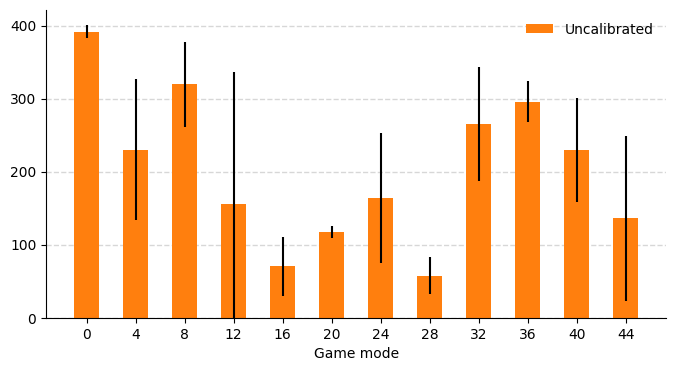

In [10]:
fig, axes = plt.subplots(figsize=(8,4))
for mode, (r_mean, r_std) in mode_results.items():
    plt.bar(
        x=mode,
        height=r_mean,
        yerr=r_std,
        width=2.0,
        color="tab:orange",
        label="Uncalibrated" if mode == 0 else None,
    )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, None)
ax.set_xticks(range(0, 45, 4))
ax.set_xlabel("Game mode")
ax.set_yticks([0, 100, 200, 300, 400])
ax.grid(axis='y', linestyle='--', linewidth=1.0, alpha=0.5)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.show()

In [11]:
from dataclasses import dataclass, field
from typing import Callable

@dataclass
class RobustnessConfig:
    """Configuration for robustness experiments.
    """

    alpha_disc: float = ALPHA_DISC
    alpha_nn: float = ALPHA_NN
    cql_alpha: float = CQL_ALPHA
    min_calib: int = MIN_CALIB
    num_experiments: int = NUM_EXPERIMENTS
    num_eval_episodes: int = NUM_EVAL_EPISODES
    n_calib_steps: int = N_CALIB_STEPS
    n_train_steps: int = N_TRAIN_STEPS
    k: int = K
    scoring_method: ScoringMethod = SCORING_METHOD
    agent_type: AgentTypes = AGENT_TYPE
    score_fn: Callable = SCORE_FN
    retrain: bool = RETRAIN
    calib_methods: list[CalibMethods] = field(default_factory=lambda: CALIB_METHODS.copy())
    ccnn_max_distance_quantile: float = CCNN_MAX_DISTANCE_QUANTILE
    debug_serial: bool = False
    debug_seed: int | None = 0

cfg = RobustnessConfig()

In [12]:
vec_env = make_atari_env(ENV_ID, n_envs=1, seed=SEED + 1, env_kwargs={'difficulty': 0, 'mode': 0})
vec_env = VecFrameStack(vec_env, n_stack=4) 

obs_space = vec_env.observation_space
n_dims = int(obs_space.shape[0])
# Sanity checks
assert getattr(vec_env, "num_envs", 1) == 1

In [13]:
n_dims

84

# trying cc-nn

In [39]:
buffer = collect_transitions(model, vec_env, n_transitions=cfg.n_calib_steps)

In [44]:
model.env = vec_env

In [46]:
vec_env.observation_space

Box(0, 255, (84, 84, 4), uint8)

In [45]:
from crl.ccnn import compute_nn_scores_td, _clip_scores, _compute_max_dist
from crl.calib import signed_score
from sklearn.neighbors import KDTree

score_fn = signed_score
score_clip_level = 0.01

scores, features, scaler = compute_nn_scores_td(
    model,
    buffer,
    score_fn=score_fn,
)

# clip the scores to remove extreme outliers
scores = _clip_scores(score_clip_level, scores)

tree = KDTree(features)
max_dist = _compute_max_dist(k, max_distance_quantile, features, tree)

ValueError: could not broadcast input array from shape (28225,) into shape (85,)

In [ ]:
ccnn_scores, scaler, tree, max_dist = calibrate_ccnn(
    model,
    buffer,
    k=cfg.k,
    score_fn=cfg.score_fn,
    scoring_method=cfg.scoring_method,
    max_distance_quantile=cfg.ccnn_max_distance_quantile,
)

In [ ]:
num_eps = 10
ep_env = vec_env
scores = ccnn_scores 


In [ ]:
episodic_returns = []

# Determine number of discrete actions
num_actions = getattr(ep_env.action_space, "n")

fallback_value = scores.max()

for ep in range(num_eps):
    obs = ep_env.reset()
    for t in range(1000):
        q_vals = model.q_net(model.policy.obs_to_tensor(obs)[0]).flatten()

        # Adjust the qvalues of each action using
        # the correction from CP
        for a in range(num_actions):
            sa_feature = np.concatenate([obs.flatten(), np.array([a])]).reshape(
                1, -1
            )
            # Scale the feature before NN search
            sa_feature = scaler.transform(sa_feature)
            dists, ids = tree.query(sa_feature, k=k)
            if np.max(dists) > max_dist:  # too far, anomalous
                correction = fallback_value  # * np.maximum(1.0, sa_maxdist)
            else:
                neighbour_scores = scores[ids]
                correction = _compute_correction(neighbour_scores, alpha=alpha)
            q_vals[a] -= correction

        # take the action
        action = q_vals.argmax().numpy().reshape(1)
        obs, reward, done, info = ep_env.step(action)

        if done:
            ep_return = info[0]["episode"]["r"]
            episodic_returns.append(ep_return)
            break

In [15]:
# obs.shape

In [ ]:
import os
os.environ["RUST_BACKTRACE"] = "full"

In [17]:
discretise, n_features = build_tile_coding(model, vec_env, tiles=4, tilings=1)
buffer = collect_transitions(model, vec_env, n_transitions=cfg.n_calib_steps)
calib_sets = fill_calib_sets_td(
    model,
    buffer,
    discretise,
)
qhats = compute_corrections(
    calib_sets,
    alpha=cfg.alpha_disc,
    min_calib=cfg.min_calib,
)

Test episodes: 100%|██████████| 1000/1000 [28:45<00:00,  1.73s/it] 

thread '<unnamed>' panicked at src/tc.rs:32:5:
attempt to calculate the remainder with a divisor of zero
stack backtrace:
   0: __rustc::rust_begin_unwind
   1: core::panicking::panic_fmt
   2: core::panicking::panic_const::panic_const_rem_by_zero
   3: PyFixedReps::tc::get_tc_indices
   4: PyFixedReps::rust::test_py
   5: PyFixedReps::rust::_::<impl PyFixedReps::rust::test_py::MakeDef>::DEF::trampoline
   6: _cfunction_call
   7: __PyObject_MakeTpCall
   8: __PyEval_EvalFrameDefault
   9: _PyEval_EvalCode
  10: _builtin_exec
  11: __PyEval_EvalFrameDefault
  12: _gen_send_ex2
  13: _gen_send_ex
  14: __PyEval_EvalFrameDefault
  15: _method_vectorcall
  16: __PyVectorcall_Call
  17: __PyEval_EvalFrameDefault
  18: _gen_send_ex2
  19: _task_step_impl
  20: _task_step
  21: _task_wakeup
  22: _cfunction_vectorcall_O
  23: __PyObject_VectorcallTstate
  24: _context_run
  25: _cfunction_vectorcall_FASTCALL_KEYWORDS
  26: 

PanicException: attempt to calculate the remainder with a divisor of zero

In [3]:
(results.keys())

dict_keys(['baseline', 'ccnn', 'ccnn-faiss-approximations'])

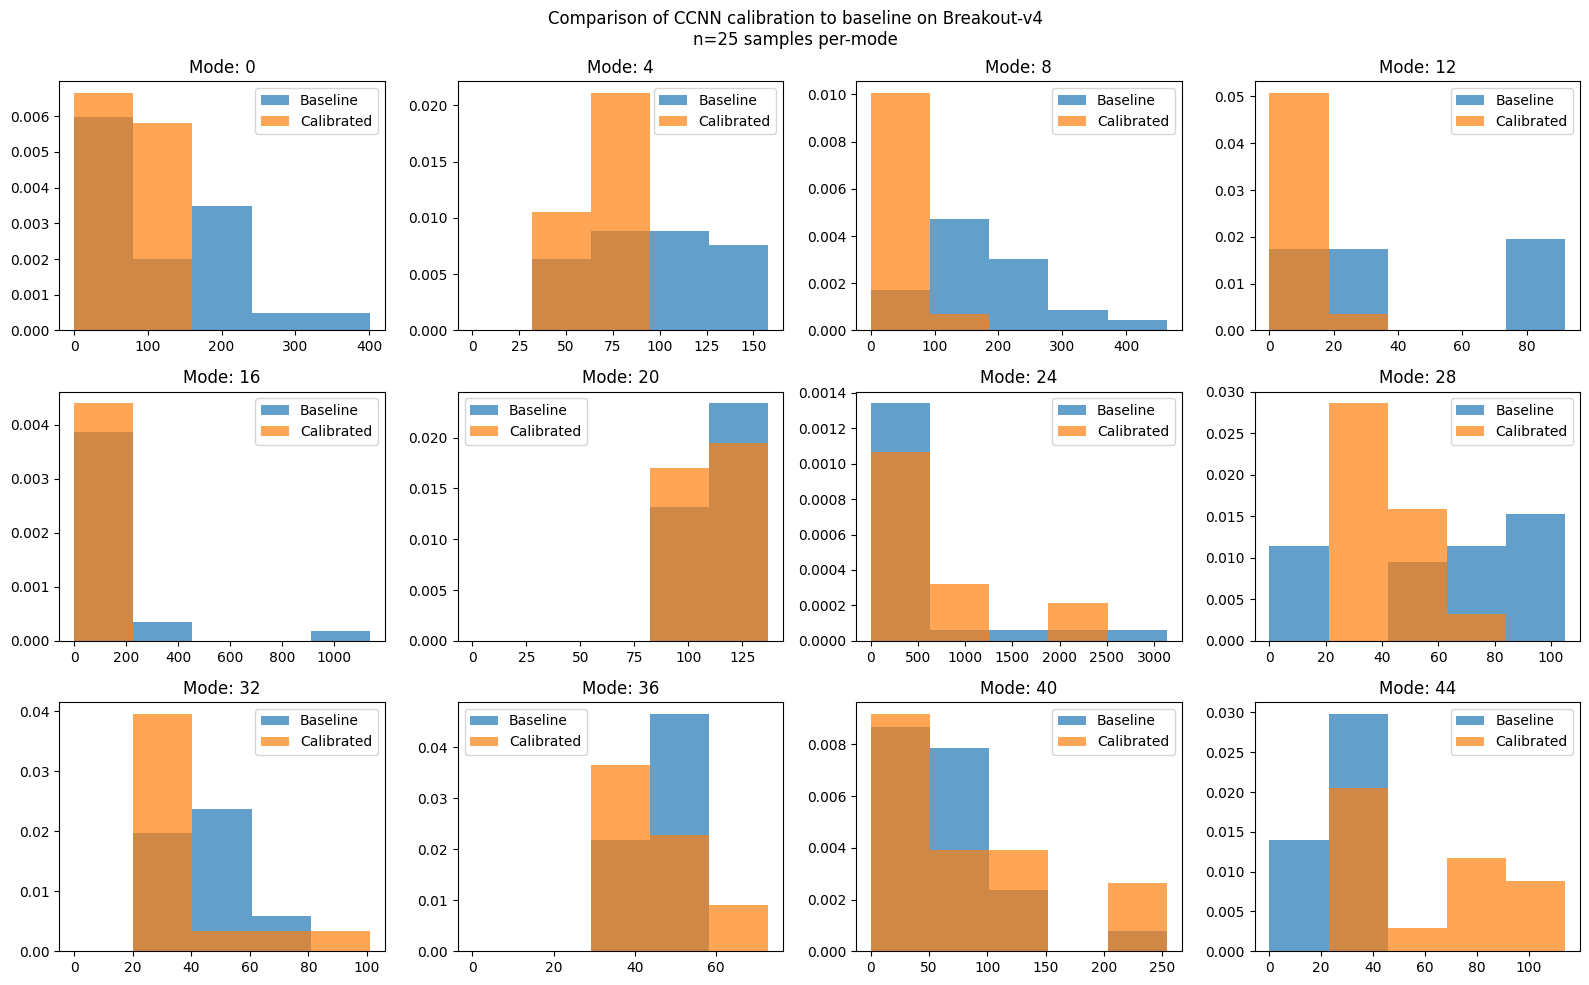

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open("ccnn_no_tuning_comparison_vectorised.pkl", "rb") as f:
    results = pickle.load(f)

with open('ccnn_no_tuning_activations_plus_faiss.pkl', 'rb') as f:
    results.update(pickle.load(f))

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
flat_axes = axes.flatten()
modes = range(0, 45, 4)

for ax, mode in zip(flat_axes, modes):
    bl = results['baseline'][mode]
    calib = results['ccnn-faiss-approximations'][mode]
    
    max_val = np.maximum(np.max(bl), np.max(calib))
    is_identical = np.array_equal(bl, calib)# or mode in (20, 40)
    
    # Style configuration
    if is_identical:
        bg_color = '#f5f5f5'  # Light grey background
        alpha_val = 0.3       # Highly transparent/desaturated bars
        line_color = '#cccccc' # Faint grey lines
        text_color = '#aaaaaa' # Faint text
    else:
        bg_color = 'white'
        alpha_val = 0.7
        line_color = 'black'
        text_color = 'black'

    ax.set_facecolor(bg_color)
    ax.set_title(f'Mode: {mode}', color=text_color)
    
    # Plotting
    ax.hist(bl, color='tab:blue', label='Baseline', alpha=alpha_val, bins=5, range=(0, max_val), density=True)
    ax.hist(calib, color='tab:orange', label='Calibrated', alpha=alpha_val, bins=5, range=(0, max_val), density=True)
    ax.set_ylim(0, None)
    # Apply de-emphasis to structural elements
    if is_identical:
        ax.tick_params(axis='both', colors=line_color) # Lighten ticks
        for spine in ax.spines.values():
            spine.set_edgecolor(line_color) # Lighten border
    else:
        pass
        ax.legend()
plt.suptitle('Comparison of CCNN calibration to baseline on Breakout-v4\nn=25 samples per-mode')
plt.tight_layout()
plt.show()

In [11]:
for mode in modes:
    bl = results['baseline'][mode]
    calib = results['ccnn-faiss-approximations'][mode]
    calib_exact = results['ccnn'][mode]
    print(f'----MODE {mode}-----')
    print(f'       BASELINE: {np.mean(bl):.1f}')
    print(f'           CCNN: {np.mean(calib_exact):.1f}')
    print(f'CCNN-ACTIVATION: {np.mean(calib):.1f}')

----MODE 0-----
       BASELINE: 136.5
           CCNN: 83.8
CCNN-ACTIVATION: 76.7
----MODE 4-----
       BASELINE: 99.5
           CCNN: 68.6
CCNN-ACTIVATION: 74.0
----MODE 8-----
       BASELINE: 191.8
           CCNN: 218.8
CCNN-ACTIVATION: 88.6
----MODE 12-----
       BASELINE: 42.2
           CCNN: 42.2
CCNN-ACTIVATION: 10.7
----MODE 16-----
       BASELINE: 166.5
           CCNN: 334.0
CCNN-ACTIVATION: 113.1
----MODE 20-----
       BASELINE: 112.5
           CCNN: 119.6
CCNN-ACTIVATION: 112.6
----MODE 24-----
       BASELINE: 450.8
           CCNN: 400.4
CCNN-ACTIVATION: 580.8
----MODE 28-----
       BASELINE: 61.3
           CCNN: 61.3
CCNN-ACTIVATION: 41.9
----MODE 32-----
       BASELINE: 42.7
           CCNN: 42.7
CCNN-ACTIVATION: 42.4
----MODE 36-----
       BASELINE: 47.6
           CCNN: 47.6
CCNN-ACTIVATION: 47.5
----MODE 40-----
       BASELINE: 58.2
           CCNN: 57.4
CCNN-ACTIVATION: 92.0
----MODE 44-----
       BASELINE: 22.7
           CCNN: 22.7
CCNN-ACTIVATION: 